# DH 参数可视化、逆解与实机控制

这个 notebook 使用当前标准 DH 参数和角度范围建立 `roboticstoolbox` 模型，支持两种模式：

- `INPUT_MODE = 'joint'`：直接输入关节模型角 `Q_DEG`
- `INPUT_MODE = 'xyz'`：输入末端目标坐标 `TARGET_POS_MM`，参考 `4、轨迹规划实操.ipynb` 的 `ikine_LM` 方法求逆解

运行流程：先仿真显示关节角、理论末端坐标和机械臂姿态；确认无误后，再把 `MOVE_REAL_ROBOT = True` 运行实物。

注意：DH 末端点不一定等于夹爪尖端；如果实测夹爪尖端，需要另外加入 TCP/工具偏移。


ikine_LM success = True
ikine_LM reason  = Success
ikine_LM residual= 1.3788150403630485e-08

求解来源: ikine_LM from xyz
目标/求解模型角 q_deg: [50.943, -0.649, 66.82, 36.269, -15.648, 0.0]
理论末端坐标 pos_mm [x, y, z]: [100.0, 160.0, 200.0]
输入目标坐标 TARGET_POS_MM: [100, 160, 200]
位置误差 mm: [-0.0, 0.0, -0.0001]
齐次变换矩阵 T:
[[-0.8019  0.1357  0.5818  0.1   ]
 [-0.5602  0.1673 -0.8113  0.16  ]
 [-0.2074 -0.9765 -0.0581  0.2   ]
 [ 0.      0.      0.      1.    ]]


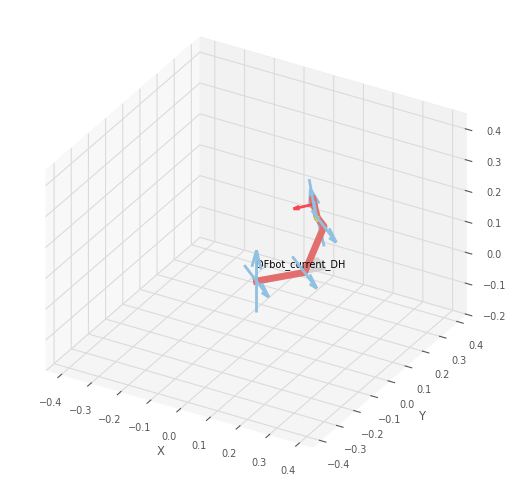

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'DFbot_current_DH')

<Figure size 640x480 with 0 Axes>

In [ ]:
import time
import numpy as np
from roboticstoolbox import DHRobot, RevoluteDH
from spatialmath import SE3
import arm_robot as robot

np.set_printoptions(precision=4, suppress=True)

# =====================
# 1. 输入模式与目标
# =====================
# 'joint': 直接使用 Q_DEG
# 'xyz': 根据 TARGET_POS_MM 逆解得到关节角
INPUT_MODE = 'xyz'

# joint 模式：模型关节角，单位：度，对应 [q1, q2, q3, q4, q5, q6]
Q_DEG = [20, 0, 0, 0, 0, 0]

# xyz 模式：末端 DH 点目标坐标，单位：mm
# 默认值对应 Q_DEG=[20,0,0,0,0,0] 的理论末端位置
TARGET_POS_MM = [100, 200, 200]

# 只根据 xyz 求逆解时，姿态不约束；如果你希望同时约束姿态，改为 False 并设置 TARGET_RPY_DEG。
POSITION_ONLY_IK = True
TARGET_RPY_DEG = [0, 0, 0]  # roll, pitch, yaw，单位：度，仅 POSITION_ONLY_IK=False 时使用
RPY_ORDER = 'zyx'

# 逆解初值。位置-only 逆解不唯一，q0 会影响结果；建议填当前姿态或期望附近的姿态。
IK_Q0_DEG = [0, 0, 0, 0, 0, 0]

# Linux 下当前实测串口是 /dev/ttyACM2；Windows 常见写法如 'COM4'
SERIAL_PORT = '/dev/ttyACM2'
UART_BAUDRATE = 115200

# 实机运动开关：先保持 False 运行本单元看图和理论坐标；确认无误后改成 True 再运行下面的实机运动单元
MOVE_REAL_ROBOT = True
MOVE_SPEED = 1.0

# 当前 notebook 使用的模型角范围，单位：度。RTB 逆解 joint_limits=True 会使用这里的范围。
MODEL_MIN_DEG = [-160, -10, -160, -160, -180, -180]
MODEL_MAX_DEG = [160, 180, 160, 160, 180, 180]


# =====================
# 2. 当前标准 DH 模型
# =====================
def build_dfbot():
    return DHRobot(
        [
            RevoluteDH(alpha=np.pi / 2, qlim=np.deg2rad([MODEL_MIN_DEG[0], MODEL_MAX_DEG[0]])),
            RevoluteDH(a=0.15, qlim=np.deg2rad([MODEL_MIN_DEG[1], MODEL_MAX_DEG[1]])),
            RevoluteDH(a=0.15, qlim=np.deg2rad([MODEL_MIN_DEG[2], MODEL_MAX_DEG[2]])),
            RevoluteDH(d=-0.05494, alpha=np.pi / 2, offset=np.pi / 2, qlim=np.deg2rad([MODEL_MIN_DEG[3], MODEL_MAX_DEG[3]])),
            RevoluteDH(d=0.068, alpha=-np.pi / 2, qlim=np.deg2rad([MODEL_MIN_DEG[4], MODEL_MAX_DEG[4]])),
            RevoluteDH(d=0.033, qlim=np.deg2rad([MODEL_MIN_DEG[5], MODEL_MAX_DEG[5]])),
        ],
        name='DFbot_current_DH',
    )


def check_model_limits(q_deg):
    q_deg = np.asarray(q_deg, dtype=float)
    lo = np.asarray(MODEL_MIN_DEG, dtype=float)
    hi = np.asarray(MODEL_MAX_DEG, dtype=float)
    bad = np.where((q_deg < lo) | (q_deg > hi))[0]
    if len(bad):
        detail = ', '.join(
            f'J{i + 1}: {q_deg[i]:.2f} not in [{lo[i]:.2f}, {hi[i]:.2f}]'
            for i in bad
        )
        raise ValueError('目标角度超过模型限位: ' + detail)


def target_transform_from_xyz():
    pos_m = np.asarray(TARGET_POS_MM, dtype=float) / 1000.0
    T_target = SE3.Trans(pos_m)
    if not POSITION_ONLY_IK:
        T_target = T_target * SE3.RPY(TARGET_RPY_DEG, unit='deg', order=RPY_ORDER)
    return T_target


def solve_q_from_input(DFbot):
    if INPUT_MODE == 'joint':
        q_deg = np.asarray(Q_DEG, dtype=float)
        check_model_limits(q_deg)
        return q_deg, 'direct joint input'

    if INPUT_MODE != 'xyz':
        raise ValueError("INPUT_MODE must be 'joint' or 'xyz'")

    T_target = target_transform_from_xyz()
    q0 = np.deg2rad(np.asarray(IK_Q0_DEG, dtype=float))
    mask = [1, 1, 1, 0, 0, 0] if POSITION_ONLY_IK else [1, 1, 1, 1, 1, 1]

    # 参考 4、轨迹规划实操.ipynb：DFbot.ikine_LM(..., q0=..., ilimit=100, slimit=100, joint_limits=True)
    sol = DFbot.ikine_LM(
        T_target,
        q0=q0,
        mask=mask,
        ilimit=100,
        slimit=100,
        joint_limits=True,
    )
    print('ikine_LM success =', sol.success)
    print('ikine_LM reason  =', getattr(sol, 'reason', ''))
    print('ikine_LM residual=', getattr(sol, 'residual', None))
    if not sol.success:
        raise RuntimeError('逆解失败，请调整 TARGET_POS_MM、IK_Q0_DEG、角度范围或姿态约束。')

    q_deg = np.rad2deg(sol.q)
    check_model_limits(q_deg)
    return q_deg, 'ikine_LM from xyz'


# =====================
# 3. 求解、打印、仿真显示
# =====================
DFbot = build_dfbot()
q_deg, q_source = solve_q_from_input(DFbot)
q_rad = np.deg2rad(q_deg)

T = DFbot.fkine(q_rad)
T_np = np.asarray(T.A if hasattr(T, 'A') else T)
pos_mm = T_np[:3, 3] * 1000

print('\n求解来源:', q_source)
print('目标/求解模型角 q_deg:', np.round(q_deg, 3).tolist())
print('理论末端坐标 pos_mm [x, y, z]:', np.round(pos_mm, 3).tolist())
if INPUT_MODE == 'xyz':
    print('输入目标坐标 TARGET_POS_MM:', TARGET_POS_MM)
    print('位置误差 mm:', np.round(pos_mm - np.asarray(TARGET_POS_MM, dtype=float), 4).tolist())
print('齐次变换矩阵 T:')
print(T_np)

# 后续实机运动单元使用这个变量
ROBOT_TARGET_DEG = q_deg.tolist()

# backend='pyplot' 适合 Jupyter/Notebook；如果图窗不显示，确认已安装 matplotlib 与 roboticstoolbox 的 pyplot 后端。
DFbot.plot(q_rad, backend='pyplot', block=False, limits=[-0.45, 0.45, -0.45, 0.45, -0.20, 0.45])

## 控制实物运动到求解出的关节角

确认上面的仿真姿态、关节角和理论坐标无误后，把上一个代码块里的 `MOVE_REAL_ROBOT` 改为 `True`，再运行下面单元。

In [43]:
def read_model_angles(ro):
    servo = ro.read_joints()
    if servo is False:
        return False, False
    return servo, ro.servo_to_model(servo)


if not MOVE_REAL_ROBOT:
    print('MOVE_REAL_ROBOT = False，未发送实机运动命令。确认仿真和角度后，改为 True 再运行本单元。')
else:
    check_model_limits(ROBOT_TARGET_DEG)
    ro = robot.arm_robot(
        L_p=0,
        L_p_mass_center=0,
        MAX_list_temp=MODEL_MAX_DEG,
        MIN_list_temp=MODEL_MIN_DEG,
        G_p=0,
        com=SERIAL_PORT,
        uart_baudrate=UART_BAUDRATE,
    )

    servo_before, model_before = read_model_angles(ro)
    print('servo_before =', servo_before)
    print('model_before =', model_before)
    if model_before is False:
        raise RuntimeError('读取当前关节角失败，停止运动。')

    print('command target model deg =', np.round(ROBOT_TARGET_DEG, 3).tolist())
    ok = ro.set_arm_joints(angle_list=ROBOT_TARGET_DEG, speed=MOVE_SPEED)
    print('command_ok =', ok)
    if ok is False:
        raise RuntimeError('set_arm_joints 返回 False，目标未执行。')

    ro.pose_done()
    time.sleep(0.5)

    servo_after, model_after = read_model_angles(ro)
    print('servo_after =', servo_after)
    print('model_after =', model_after)

    if model_after is not False:
        T_after = DFbot.fkine(np.deg2rad(model_after))
        T_after_np = np.asarray(T_after.A if hasattr(T_after, 'A') else T_after)
        print('按回读模型角计算的 DH 末端坐标 mm =', np.round(T_after_np[:3, 3] * 1000, 3).tolist())

位置增益 P：10.0
积分增益 I：5.0
转速增益 D：0.550000011920929
机械臂第  1  号关节的 PID 修改为： [10.0, 5.0, 0.550000011920929]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  2  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  3  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.0
积分增益 I：9.0
转速增益 D：0.5
机械臂第  4  号关节的 PID 修改为： [10.0, 9.0, 0.5]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.10000000149011612
机械臂第  5  号关节的 PID 修改为： [12.0, 5.0, 0.10000000149011612]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.09600000083446503
机械臂第  6  号关节的 PID 修改为： [12.0, 5.0, 0.09600000083446503]
初始化成功
servo_before = [38.61366271972656, 0.45395851135253906, 76.19190979003906, -41.52736282348633, -17.905052185058594, 0.18465399742126465]
model_before = [38.6, -0.5, 76.2, 41.5, -17.9, 0.2]
command target model deg = [50.943, -0.649, 66.82, 36.269, -15.648, 0.0]
command_ok = True
servo_afte

## 可选：回零

如需回到 `[0, 0, 0, 0, 0, 0]`，把 `MOVE_HOME = True` 后运行下面单元。

In [ ]:
MOVE_HOME = False
HOME_DEG = [0, 0, 0, 0, 0, 0]

if not MOVE_HOME:
    print('MOVE_HOME = False，未发送回零命令。')
else:
    home = np.asarray(HOME_DEG, dtype=float)
    check_model_limits(home)
    ro = robot.arm_robot(
        L_p=0,
        L_p_mass_center=0,
        MAX_list_temp=MODEL_MAX_DEG,
        MIN_list_temp=MODEL_MIN_DEG,
        G_p=0,
        com=SERIAL_PORT,
        uart_baudrate=UART_BAUDRATE,
    )
    print('model_before =', read_model_angles(ro)[1])
    ok = ro.set_arm_joints(angle_list=home.tolist(), speed=MOVE_SPEED)
    print('command_ok =', ok)
    ro.pose_done()
    time.sleep(0.5)
    print('model_after =', read_model_angles(ro)[1])